# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Q1 Answers**
1. We use them because real-world relationships are often not strictly linear. These methods allow us to model more complex patterns, like probabilities or nonlinear relationships, instead of just straight lines. They give us more flexibility and better accuracy than basic linear models.
2. They are effective because they measure how close the predicted probabilities are to the true labels. They heavily penalize confident wrong predictions, which helps the model learn better probabilities and improves classification performance.
3. True, It is linear in terms of the coefficients, even though the output is passed through a nonlinear function.
4. False, logistic regression is commonly used for classification because it outputs probabilities that can be turned into class labels (like 0 or 1).
5. No, the coefficient represents the change in the log-odds of the outcome, not the direct change in the predicted probability.
6. False, feature engineering is still important because logistic regression is linear in the inputs. If the relationship is complex, new features may need to be created
7. False, logistic regression is better for classification problems, but linear regression is better for predicting continuous values. The choice depends on the problem, not one being always better.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [1]:
!git clone https://github.com/Marco-Velazz/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 24 (delta 4), reused 4 (delta 4), pack-reused 16 (from 1)
Receiving objects: 100% (24/24), 25.56 KiB | 3.20 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Download complete
Extracting data files...
Data extracted


In [2]:
import pandas as pd

df = pd.read_csv("/content/data/data.csv", sep=";")

# Keep only the variables we need
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]

df = df[cols]

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values per column:")
print(df.isna().sum())

print("\nTarget counts:")
print(df["Target"].value_counts(dropna=False))

Shape: (4424, 6)

Column names:
['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']

First 5 rows:
   Debtor  Tuition fees up to date  Scholarship holder  Age at enrollment  \
0       0                        1                   0                 20   
1       0                        0                   0                 19   
2       0                        0                   0                 19   
3       0                        1                   0                 20   
4       0                        1                   0                 45   

   Curricular units 1st sem (approved)    Target  
0                                    0   Dropout  
1                                    6  Graduate  
2                                    0   Dropout  
3                                    6  Graduate  
4                                    5  Graduate  

Missing values per column:
Debtor                    

In [3]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Create binary target: 1 = Dropout, 0 = Not Dropout
df["Dropout_binary"] = np.where(df["Target"] == "Dropout", 1, 0)

X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]

y = df["Dropout_binary"]

# Fit logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})

print(coef_df)
print("\nIntercept:", model.intercept_[0])

                  Variable  Coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925

Intercept: 0.4856926578796168


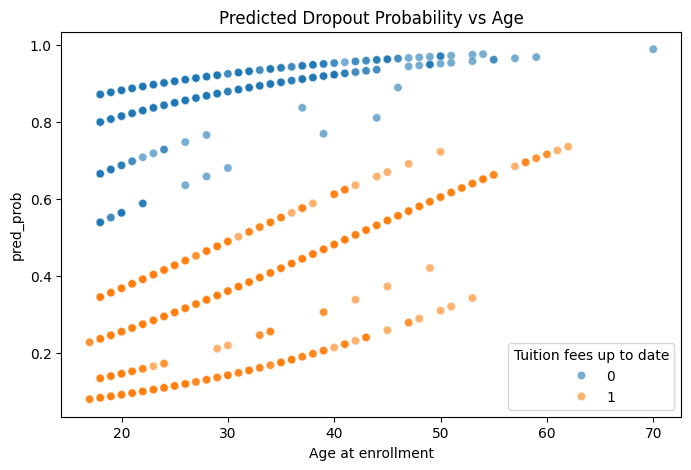

Average predicted probabilities:
Tuition fees up to date
0    0.860675
1    0.248090
Name: pred_prob, dtype: float64

Average reduction when tuition is up to date: 0.6125849339840048


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicted probabilities (probability of dropout = class 1)
df["pred_prob"] = model.predict_proba(X)[:, 1]

# Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Age at enrollment",
    y="pred_prob",
    hue="Tuition fees up to date",
    alpha=0.6
)

plt.title("Predicted Dropout Probability vs Age")
plt.show()

# Average effect of tuition being up to date
avg_by_tuition = df.groupby("Tuition fees up to date")["pred_prob"].mean()
print("Average predicted probabilities:")
print(avg_by_tuition)

diff = avg_by_tuition[0] - avg_by_tuition[1]
print("\nAverage reduction when tuition is up to date:", diff)

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Predictions (0 or 1)
y_pred = model.predict(X)

# Confusion matrix
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

acc = accuracy_score(y, y_pred)
print("\nAccuracy:", acc)

Confusion Matrix:
 [[2841  162]
 [ 891  530]]

Accuracy: 0.7619801084990958


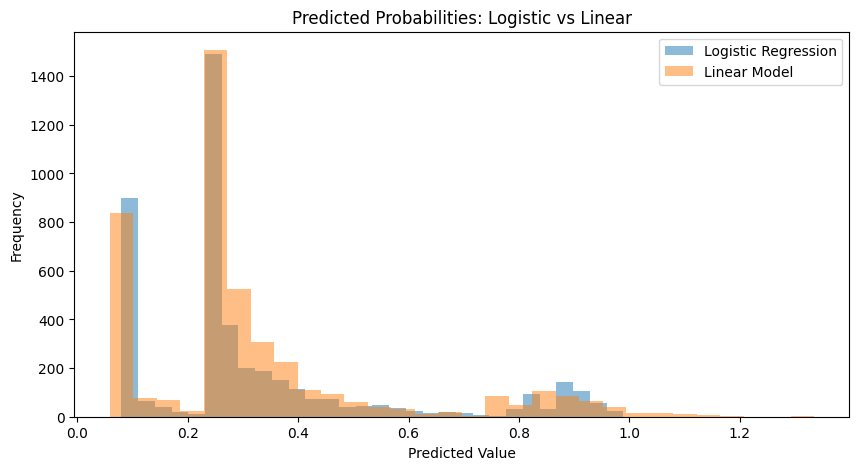

Logistic min/max: 0.0794707837723452 0.9891329873410378
Linear min/max: 0.05832035022573856 1.3349535706758708


In [6]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

# Predicted "probabilities" from linear model
df["lin_pred"] = lin_model.predict(X)

# Plot histograms
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["pred_prob"], bins=30, alpha=0.5, label="Logistic Regression")
plt.hist(df["lin_pred"], bins=30, alpha=0.5, label="Linear Model")

plt.legend()
plt.title("Predicted Probabilities: Logistic vs Linear")
plt.xlabel("Predicted Value")
plt.ylabel("Frequency")
plt.show()

# Check range of predictions
print("Logistic min/max:", df["pred_prob"].min(), df["pred_prob"].max())
print("Linear min/max:", df["lin_pred"].min(), df["lin_pred"].max())

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Features for multinomial model
X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]

y_multi = df["Target"]

# Multinomial logistic regression
multi_model = LogisticRegression(max_iter=1000, multi_class="multinomial")
multi_model.fit(X_multi, y_multi)

# Predictions
y_multi_pred = multi_model.predict(X_multi)

# Confusion matrix
cm_multi = confusion_matrix(y_multi, y_multi_pred)
print("Confusion Matrix:\n", cm_multi)

# Predicted probabilities
probs = multi_model.predict_proba(X_multi)

print("\nFirst 5 probability rows:")
print(probs[:5])

print("\nClasses:", multi_model.classes_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Confusion Matrix:
 [[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]

First 5 probability rows:
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]

Classes: ['Dropout' 'Enrolled' 'Graduate']


**Q2 Answers**
1. I loaded the dataset using sep=";" since it was semicolon-separated. I filtered the dataset to only include the relevant variables. There were no missing values in any of the columns, so no cleaning or imputation was needed.
2. Debtor and Age at enrollment have positive coefficients, so they increase the probability of dropout. Tuition fees up to date and Scholarship holder have negative coefficients, so they decrease the probability of dropout. Being up to date on tuition strongly reduces dropout risk.
3. From the predicted probabilities:
- Students not up to date on tuition have an average dropout probability of about 0.86
- Students up to date have about 0.25

  So being up to date on tuition reduces dropout probability by about 0.61 (61%) on average. From the plot, this reduction is noticeable across all ages but is especially clear for younger to middle-aged students.
4. The overall accuracy is about 0.762 (76.2%), meaning the model correctly classifies most students.

5. The logistic regression model produces probabilities between 0 and 1, which makes sense. The linear model produces values greater than 1 (up to about 1.33), which are not valid probabilities. The histogram also shows that logistic regression gives more realistic predictions, so it performs better for this task.

6. The most at-risk students are those who:
- Have outstanding debt
- Are not up to date on tuition
- Are not scholarship holders
- Are older

  Possible interventions could include financial support, payment plans, scholarships, and academic advising to help students stay on track.

7. The confusion matrix shows that the model predicts Dropout and Graduate, but it does not predict the Enrolled class at all in the hard classification. However, the predicted probabilities do assign values to all three classes. This means the model can recognize all classes probabilistically, but when making final predictions, it tends to ignore one clas

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [8]:
import pandas as pd

df2 = pd.read_csv("/content/data/cirrhosis.csv")

print("Shape:", df2.shape)

print("\nColumns:")
print(df2.columns.tolist())

print("\nFirst 5 rows:")
print(df2.head())

print("\nMissing values:")
print(df2.isna().sum())

print("\nStatus counts:")
print(df2["Status"].value_counts(dropna=False))

print("\nEdema values:")
print(df2["Edema"].value_counts(dropna=False))

print("\nDrug values:")
print(df2["Drug"].value_counts(dropna=False))

Shape: (418, 20)

Columns:
['ID', 'N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']

First 5 rows:
   ID  N_Days Status             Drug    Age Sex Ascites Hepatomegaly Spiders  \
0   1     400      D  D-penicillamine  21464   F       Y            Y       Y   
1   2    4500      C  D-penicillamine  20617   F       N            Y       Y   
2   3    1012      D  D-penicillamine  25594   M       N            N       N   
3   4    1925      D  D-penicillamine  19994   F       N            Y       Y   
4   5    1504     CL          Placebo  13918   F       N            Y       Y   

  Edema  Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  \
0     Y       14.5        261.0     2.60   156.0    1718.0  137.95   
1     N        1.1        302.0     4.14    54.0    7394.8  113.52   
2     S        1.4        176.0     3.48  

In [9]:
import numpy as np

df2 = df2[["Status", "Drug", "Edema", "Bilirubin", "Stage"]]

# Drop rows with missing Drug
df2 = df2.dropna(subset=["Drug"])

# Create binary survival variable: 1 = alive (C or CL), 0 = dead (D)
df2["Survival"] = np.where(df2["Status"].isin(["C", "CL"]), 1, 0)

# Encode Drug: 1 = D-penicillamine, 0 = Placebo
df2["Drug_binary"] = np.where(df2["Drug"] == "D-penicillamine", 1, 0)

# One-hot encode Edema
df2 = pd.get_dummies(df2, columns=["Edema"], drop_first=True)

print("Shape after cleaning:", df2.shape)
print("\nColumns now:")
print(df2.columns)

print("\nPreview:")
print(df2.head())

Shape after cleaning: (312, 8)

Columns now:
Index(['Status', 'Drug', 'Bilirubin', 'Stage', 'Survival', 'Drug_binary',
       'Edema_S', 'Edema_Y'],
      dtype='object')

Preview:
  Status             Drug  Bilirubin  Stage  Survival  Drug_binary  Edema_S  \
0      D  D-penicillamine       14.5    4.0         0            1    False   
1      C  D-penicillamine        1.1    3.0         1            1    False   
2      D  D-penicillamine        1.4    4.0         0            1     True   
3      D  D-penicillamine        1.8    4.0         0            1     True   
4     CL          Placebo        3.4    3.0         1            0    False   

   Edema_Y  
0     True  
1    False  
2    False  
3    False  
4    False  


In [10]:
from sklearn.linear_model import LogisticRegression

X2 = df2[["Drug_binary", "Bilirubin", "Edema_S", "Edema_Y"]]
y2 = df2["Survival"]

# Fit model
model2 = LogisticRegression(max_iter=1000)
model2.fit(X2, y2)

# Coefficients
coef_df2 = pd.DataFrame({
    "Variable": X2.columns,
    "Coefficient": model2.coef_[0]
})

print(coef_df2)
print("\nIntercept:", model2.intercept_[0])

      Variable  Coefficient
0  Drug_binary    -0.231952
1    Bilirubin    -0.351450
2      Edema_S    -0.451483
3      Edema_Y    -1.613160

Intercept: 1.6116486564631063


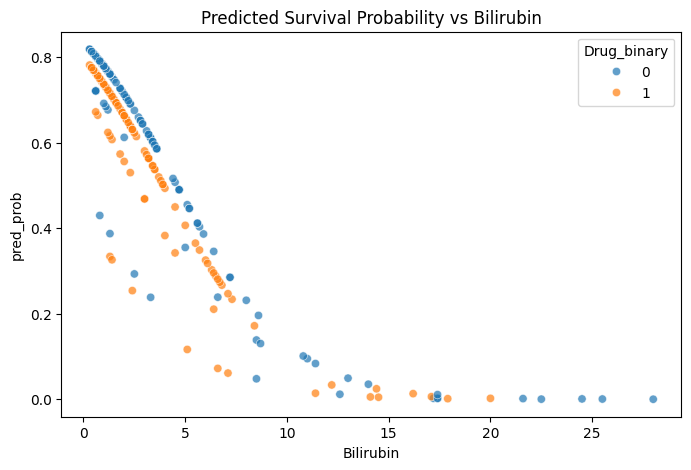

Average survival probabilities:
Drug_binary
0    0.608971
1    0.589990
Name: pred_prob, dtype: float64

Average change with drug: -0.018980879606600998


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicted survival probabilities
df2["pred_prob"] = model2.predict_proba(X2)[:, 1]

# Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df2,
    x="Bilirubin",
    y="pred_prob",
    hue="Drug_binary",
    alpha=0.7
)

plt.title("Predicted Survival Probability vs Bilirubin")
plt.show()

# Average survival probability by drug
avg_survival = df2.groupby("Drug_binary")["pred_prob"].mean()
print("Average survival probabilities:")
print(avg_survival)

diff = avg_survival[1] - avg_survival[0]
print("\nAverage change with drug:", diff)

In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Predictions
y2_pred = model2.predict(X2)

# Confusion matrix
cm2 = confusion_matrix(y2, y2_pred)
print("Confusion Matrix:\n", cm2)

# Accuracy
acc2 = accuracy_score(y2, y2_pred)
print("\nAccuracy:", acc2)

Confusion Matrix:
 [[ 59  66]
 [ 16 171]]

Accuracy: 0.7371794871794872


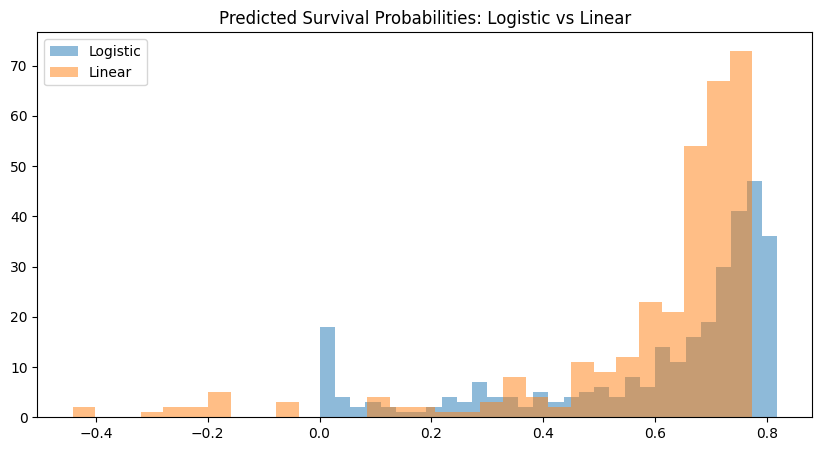

Logistic min/max: 0.0001698505017129828 0.8184994117437245
Linear min/max: -0.44173966839359724 0.7738680250928711


In [13]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Linear model
lin_model2 = LinearRegression()
lin_model2.fit(X2, y2)

# Predictions
df2["lin_pred"] = lin_model2.predict(X2)

# Histogram comparison
plt.figure(figsize=(10,5))

plt.hist(df2["pred_prob"], bins=30, alpha=0.5, label="Logistic")
plt.hist(df2["lin_pred"], bins=30, alpha=0.5, label="Linear")

plt.legend()
plt.title("Predicted Survival Probabilities: Logistic vs Linear")
plt.show()

# Min/max
print("Logistic min/max:", df2["pred_prob"].min(), df2["pred_prob"].max())
print("Linear min/max:", df2["lin_pred"].min(), df2["lin_pred"].max())

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Drop missing Stage values
df_stage = df2.dropna(subset=["Stage"])

# Features + target
X_stage = df_stage[["Bilirubin", "Edema_S", "Edema_Y"]]
y_stage = df_stage["Stage"]

# Fit multinomial logistic regression
stage_model = LogisticRegression(max_iter=1000)
stage_model.fit(X_stage, y_stage)

# Predictions
y_stage_pred = stage_model.predict(X_stage)

# Confusion matrix
cm_stage = confusion_matrix(y_stage, y_stage_pred)
print("Confusion Matrix:\n", cm_stage)

# Probabilities
stage_probs = stage_model.predict_proba(X_stage)

print("\nFirst 5 probability rows:")
print(stage_probs[:5])

print("\nClasses:", stage_model.classes_)

Confusion Matrix:
 [[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]

First 5 probability rows:
[[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]
 [2.32719781e-02 1.76777228e-01 3.97216502e-01 4.02734292e-01]
 [2.02038998e-02 2.24965391e-01 4.23342268e-01 3.31488440e-01]]

Classes: [1. 2. 3. 4.]


**Q3 Answers**
1. I loaded the cirrhosis dataset and filtered it to only include Status, Drug, Edema, Bilirubin, and Stage. Since Drug had missing values, I dropped those rows. The other variables used did not have missing values after this step.
2. The coefficient for Drug is slightly negative, so the drug does not improve survival and may slightly decrease it. Bilirubin has a negative coefficient, meaning higher bilirubin is associated with lower survival probability. Edema also has negative effects: mild edema lowers survival, and severe edema lowers survival even more, showing worse outcomes with more swelling.
3. From the predicted probabilities:
- Placebo group: ~0.609 survival probability
- Drug group: ~0.590 survival probability

  So the drug decreases survival probability by about 0.019 (~2%) on average, which is very small. From the plot, survival probability decreases as bilirubin increases, and the drug does not noticeably improve survival at any bilirubin level.

4. The accuracy is about 0.737 (73.7%), meaning the model correctly predicts survival status most of the time.
5. The logistic regression model produces probabilities between 0 and 1, which are valid. The linear model produces values below 0 (around −0.44), which are not valid probabilities. The histogram also shows logistic regression gives more realistic predictions, so it performs better for this task.
6. The confusion matrix shows that the model mostly predicts Stage 3 and Stage 4, and does not predict Stage 1 or Stage 2 at all in the hard classification. However, the predicted probabilities include all four stages. This means the model can assign probability to all classes, but when making final predictions, it ignores some classes and favors the more common ones.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

**Q4 Answers**
1.

$$
\hat{y} = b_0 + \sum_{k=1}^K b_k x_k
$$

$$
\frac{\partial \hat{y}}{\partial x_k} = b_k
$$

$$
\Delta \hat{y} = b_k
$$

So for a 1-unit change in *x*k, the prediction changes by exactly *b*k. This is constant and does not depend on *x*.

2.

$$
\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}
$$

Using the chain rule:

$$
\frac{\partial \hat{p}}{\partial x_k} = \frac{\partial \hat{p}}{\partial L} \cdot \frac{\partial L}{\partial x_k}
$$

$$
= \hat{p}(1 - \hat{p}) \cdot b_k
$$

$$
\frac{\partial \hat{p}}{\partial x_k} = b_k \hat{p}(1 - \hat{p})
$$

This depends on $\hat{p}$, so the effect changes as $x$ changes. This is different from the linear model, where the effect is constant.

Since $\hat{p}(1 - \hat{p})$ is maximized at $\hat{p} = 0.5$:

$$
\frac{\partial \hat{p}}{\partial x_k} \approx \frac{b_k}{4}
$$

So when $\hat{p} \approx 0.5$, $4b_k$ is roughly the change in prediction for a 1 unit increase in $x_k$.

3.

The left-hand side is the log odds ratio, and the right-hand side is the linear model.

$$
\frac{\partial}{\partial x_k} \log \left( \frac{\hat{p}}{1 - \hat{p}} \right) = b_k
$$

So, a one unit increase in $x_k$ changes the log odds ratio by:

$$
\Delta \log \left( \frac{\hat{p}}{1 - \hat{p}} \right) = b_k
$$